In [125]:
from desc.equilibrium import Equilibrium
from desc.continuation import solve_continuation_automatic
from desc.geometry import FourierRZToroidalSurface
from desc.profiles import PowerSeriesProfile
import jax.numpy as jnp
import numpy as np
from desc.io import load
import matplotlib.pyplot as plt

save_dir = "results/"
# xi_theta = np.load(f"{save_dir}xi_theta_{save_tag}.npy")
# xi_zeta = np.load(f"{save_dir}xi_zeta_{save_tag}.npy")
I_coeffs_base = np.array(
    [
        -3.15111573e-08,
        7.16194786e03,
        7.95861633e02,
        7.95781352e02,
        -1.19289606e-02,
        -3.19292792e-03,
        -4.34680863e-03,
    ]
)
p_coeffs = np.array([0.125, 0, 0, 0, -0.125])
integrated_I = np.sum(I_coeffs_base / (n + 1))

Text(0.5, 0.98, 'Axisymmetric $n=0$ modes')

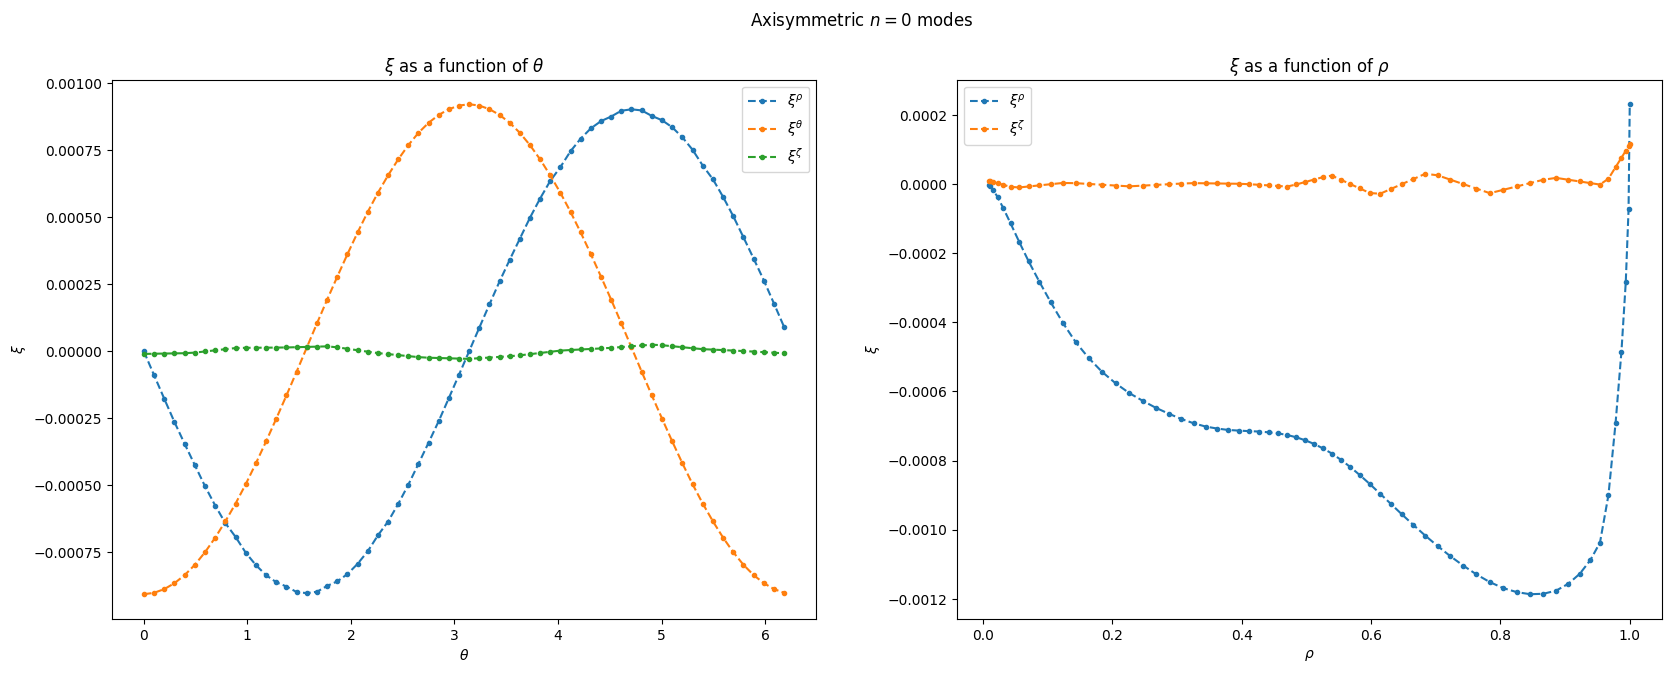

In [179]:
save_dir = "results/axisym_true/"
save_tag = "axisym_True_ar_200_NFP_1_p_0.125_0.0_0.0_0.0_-0.125_I_-3.15111573e-08_7161.94786_795.861633_795.781352_-0.0119289606_-0.00319292792_-0.00434680863"

fig, ax = plt.subplots(1,2,figsize=(20,7))
xi_rho = np.load(save_dir + f"xi_rho_{save_tag}.npy")
xi_theta = np.load(save_dir + f"xi_theta_{save_tag}.npy")
xi_zeta = np.load(save_dir + f"xi_zeta_{save_tag}.npy")

n_rho, n_theta, n_zeta = xi_rho.shape
nodes = np.load(save_dir + f"rtz_nodes_{save_tag}.npy").reshape(n_rho,n_theta,n_zeta,3)
ax[0].plot(nodes[n_rho//2,:,0,1],xi_rho[n_rho//2,:,0], linestyle="dashed",marker=".", label="$\\xi^\\rho$")
ax[0].plot(nodes[n_rho//2,:,0,1],xi_theta[n_rho//2,:,0], linestyle="dashed",marker=".", label="$\\xi^\\theta$")
ax[0].plot(nodes[n_rho//2,:,0,1],xi_zeta[n_rho//2,:,0], linestyle="dashed",marker=".", label="$\\xi^\\zeta$")
ax[0].set_xlabel("$\\theta$")
ax[0].set_ylabel("$\\xi$")
ax[0].set_title("$\\xi$ as a function of $\\theta$")
ax[0].legend()

ax[1].plot(nodes[:,10,0,0],xi_rho[:,10,0], linestyle="dashed",marker=".", label="$\\xi^\\rho$")
#ax[1].plot(nodes[:,10,0,0],xi_theta[:,10,0], linestyle="dashed",marker=".", label="$\\xi^\\theta$")
ax[1].plot(nodes[:,10,0,0],xi_zeta[:,10,0], linestyle="dashed",marker=".", label="$\\xi^\\zeta$")
ax[1].set_xlabel("$\\rho$")
ax[1].set_ylabel("$\\xi$")
ax[1].set_title("$\\xi$ as a function of $\\rho$")

ax[1].legend()
fig.suptitle("Axisymmetric $n=0$ modes")

In [171]:
print(np.load(save_dir + f"lambda_{save_tag}.npy"))
save_tag_2 = get_save_tag(I_coeffs_base, 1, p_coeffs=p_coeffs, aspect_ratio=200, NFP=1, axisym=False, fixed_iota=False)
save_dir_2 = "results/full_eigenfunction_save/"
print(np.load(save_dir_2 + f"lambda_{save_tag_2}.npy"))

[-9.85957824e-10  1.73423239e-05  7.97190460e-05  9.67816543e-05
  1.57337478e-04  1.78617127e-04  2.11212432e-03  2.39301818e-03
  6.56816062e-02  2.31756822e+00]
[-3.00207231e-07 -4.22122202e-11  3.69410755e-05  5.19619327e-05
  8.15201311e-05  1.66663049e-04  2.23224350e-04  2.47896136e-03
  1.08180783e-01  4.53904522e+00]


# plotting other eigenfunctions

In [127]:
save_dir = "results/full_eigenfunction_save/"
def get_save_tag(I_coeffs_base=I_coeffs_base, I_multiplier=1, p_coeffs=p_coeffs, aspect_ratio=200, NFP=1, axisym=False, fixed_iota=False, iota_coeffs=None):
    if fixed_iota:
        iota_coeffs = np.array([0.9, 0, 0.1, 0, 0.1])
        I_coeffs = None
    else:
        #I_coeffs = np.array([0, 0, I, 0, - I/2])
        #I_profile = PowerSeriesProfile(I_coeffs)
        # This is the current profile that corresponds to the iota profile above
        I_coeffs = I_coeffs_base * I_multiplier
        iota_coeffs = None
    p_coeffs = np.array([0.125, 0, 0, 0, -0.125])

    # Save directory and filename
    profile_tag = f"iota_{"_".join(iota_coeffs.astype(str))}" if fixed_iota else f"I_{"_".join(I_coeffs.astype(str))}"
    save_tag = f"axisym_{axisym}_ar_{aspect_ratio}_NFP_{NFP}_p_{"_".join(p_coeffs.astype(str))}_{profile_tag}"

    return save_tag


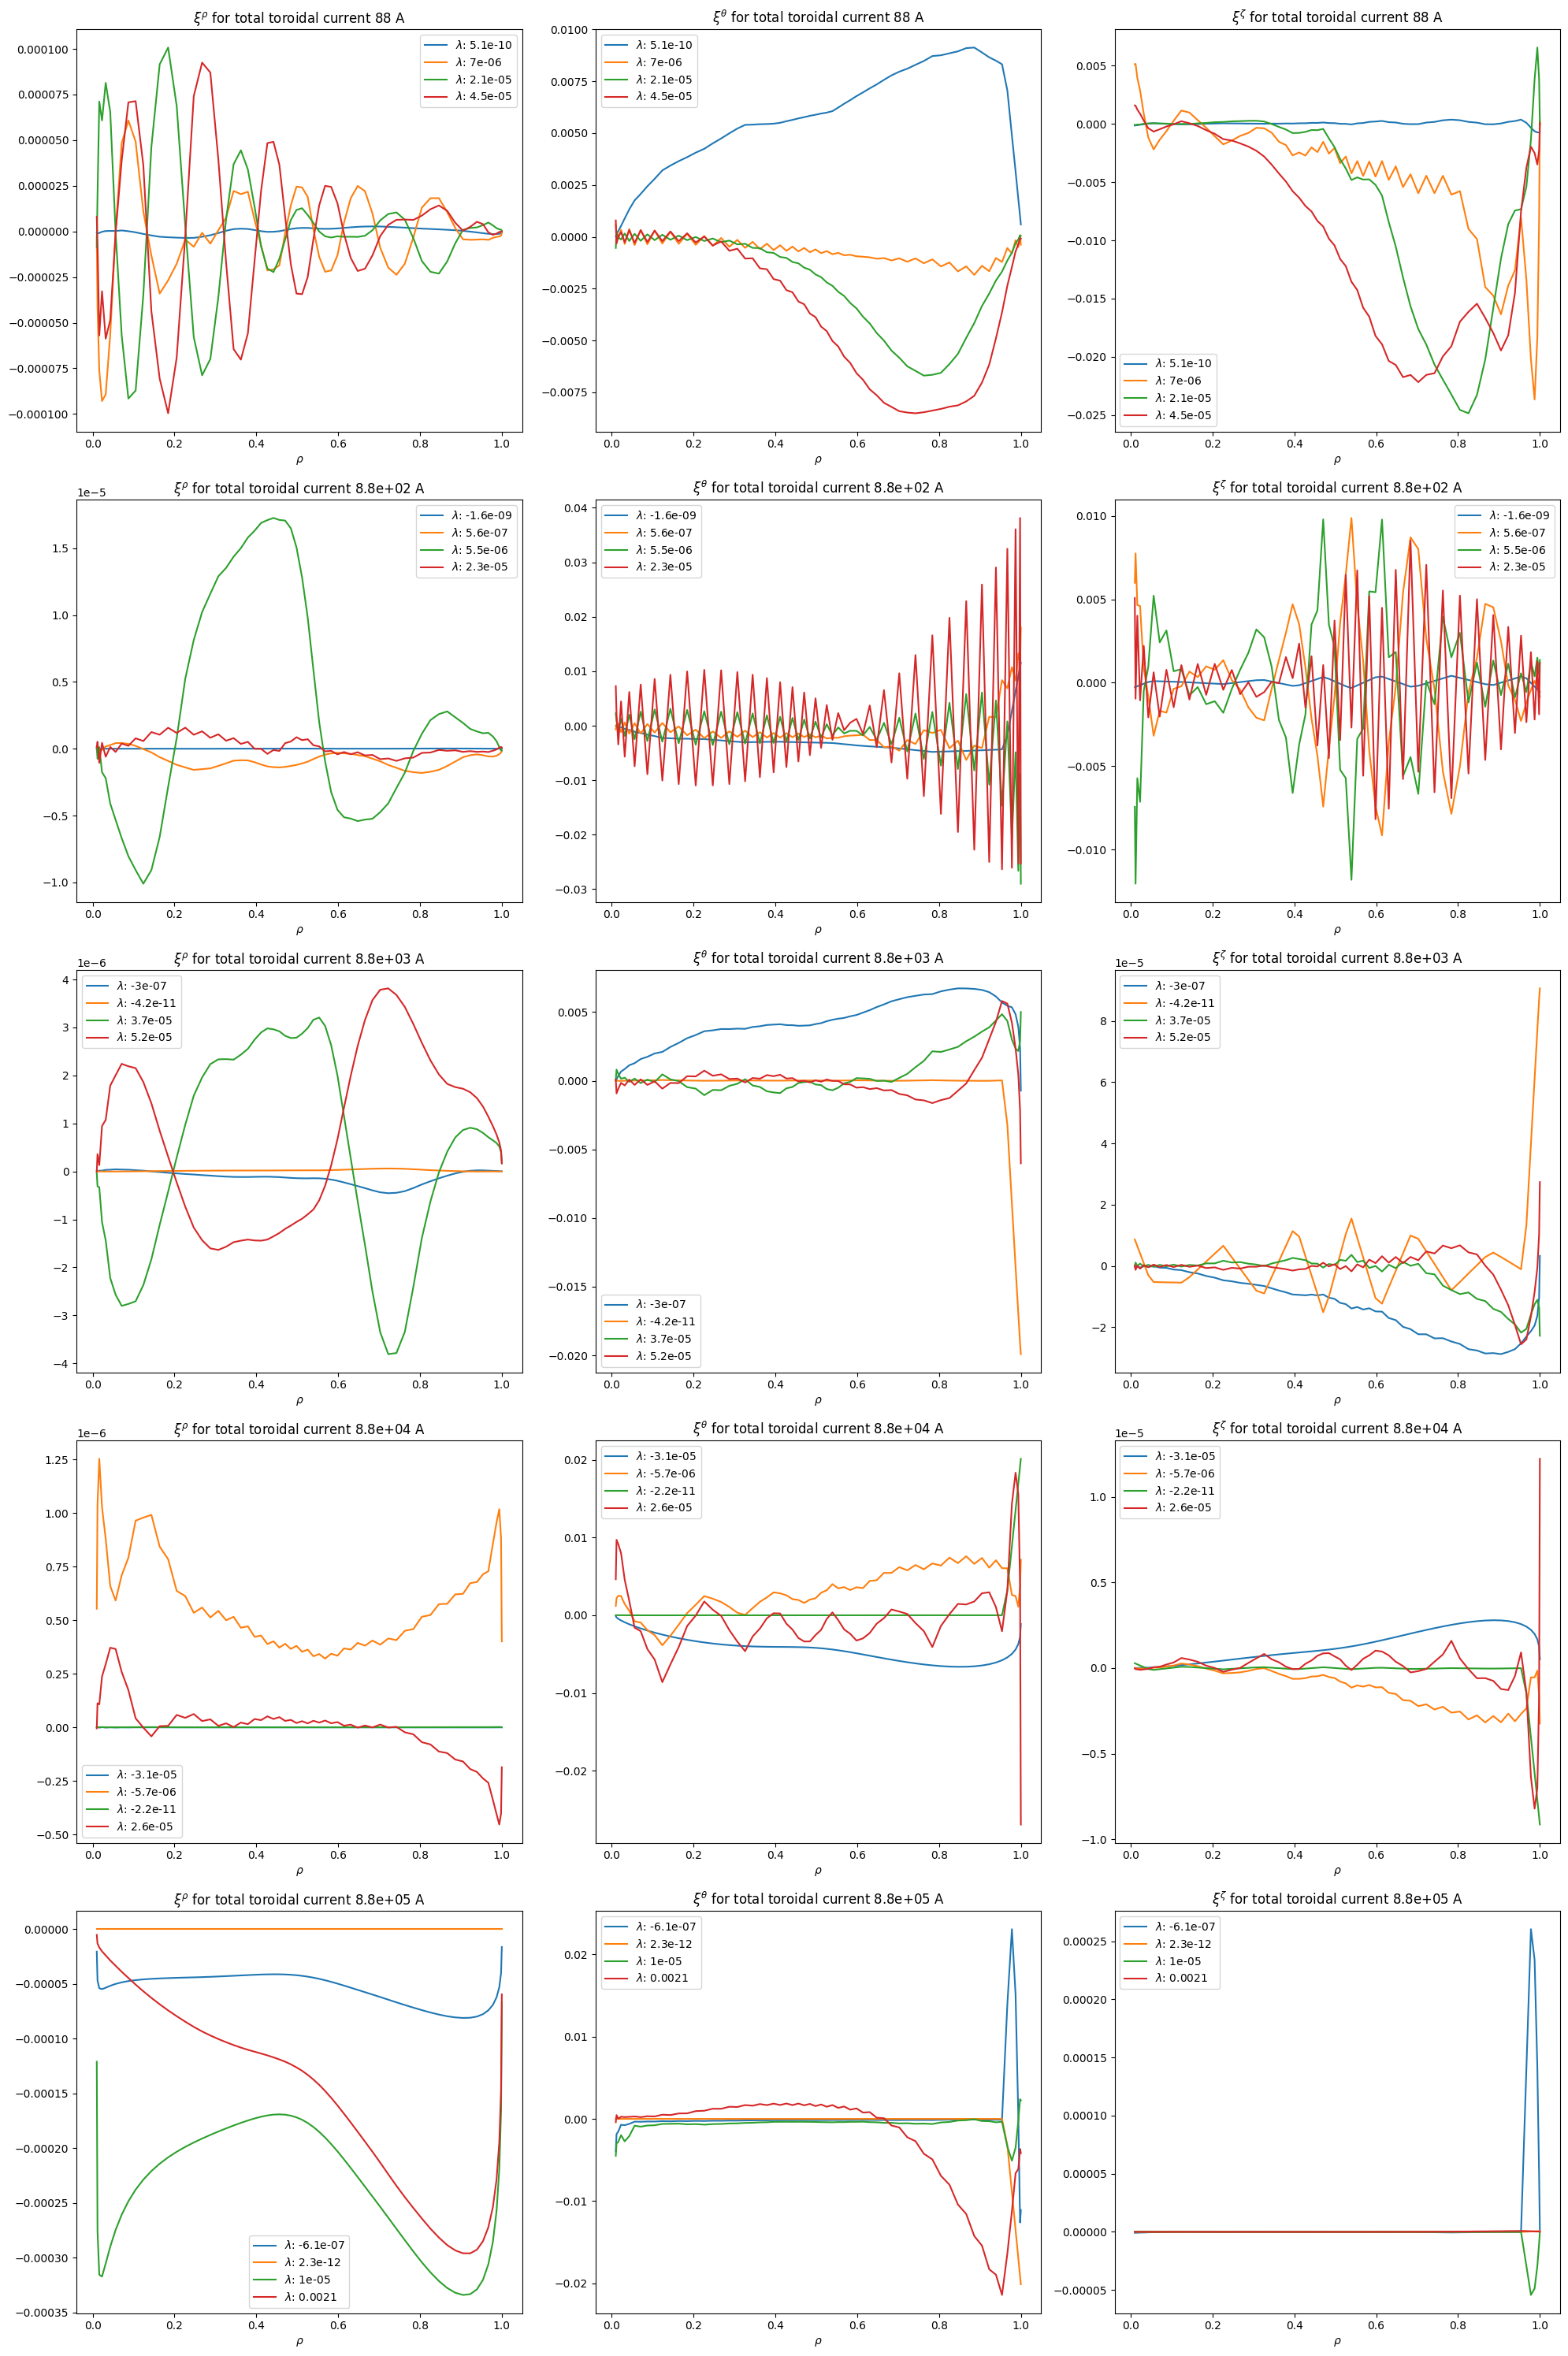

In [ ]:
# Plot as a function of rho
I_multipliers = np.logspace(-2, 2, num=5)
fig, axes = plt.subplots(5,3, figsize=(20, 30))
for I_multiplier, axs in zip(I_multipliers, axes):
    save_tag = get_save_tag(I_coeffs_base, I_multiplier, p_coeffs=p_coeffs, aspect_ratio=200, NFP=1, axisym=False, fixed_iota=False)
    v = np.load(f"{save_dir}eigenfunction_{save_tag}.npy")
    nodes = np.load(f"{save_dir}rtz_nodes_{save_tag}.npy")
    lambdas = np.load(f"{save_dir}lambda_{save_tag}.npy")
    n_rho, n_theta, n_zeta = np.load(f"{save_dir}xi_rho_{save_tag}.npy").shape
    n_total = n_rho * n_theta * n_zeta
    n_lambdas = v.shape[0]
    xi_sup_rho_final = np.reshape(v[:,:n_total], (n_lambdas, n_rho, n_theta, n_zeta))
    xi_sup_theta_final = np.reshape(v[:,n_total:2*n_total], (n_lambdas, n_rho, n_theta, n_zeta))
    xi_sup_zeta_final = np.reshape(v[:,2*n_total:], (n_lambdas, n_rho, n_theta, n_zeta))

    nodes = nodes.reshape((n_rho, n_theta, n_zeta, 3))
    for xi, ax, name in zip([xi_sup_rho_final, xi_sup_theta_final, xi_sup_zeta_final], axs, ["rho", "theta", "zeta"]):
        n_xi = 4
        ax.plot(nodes[:,0,0,0],xi[:n_xi,:,0,0].T, label = [f"$\\lambda$: {_lambda:.2g}" for _lambda in lambdas[:n_xi]])
        ax.set_title(f"$\\xi^\\{name}$ for total toroidal current {(I_multiplier * integrated_I):.2g} A")
        ax.set_xlabel("$\\rho$")
        ax.legend()
plt.tight_layout()

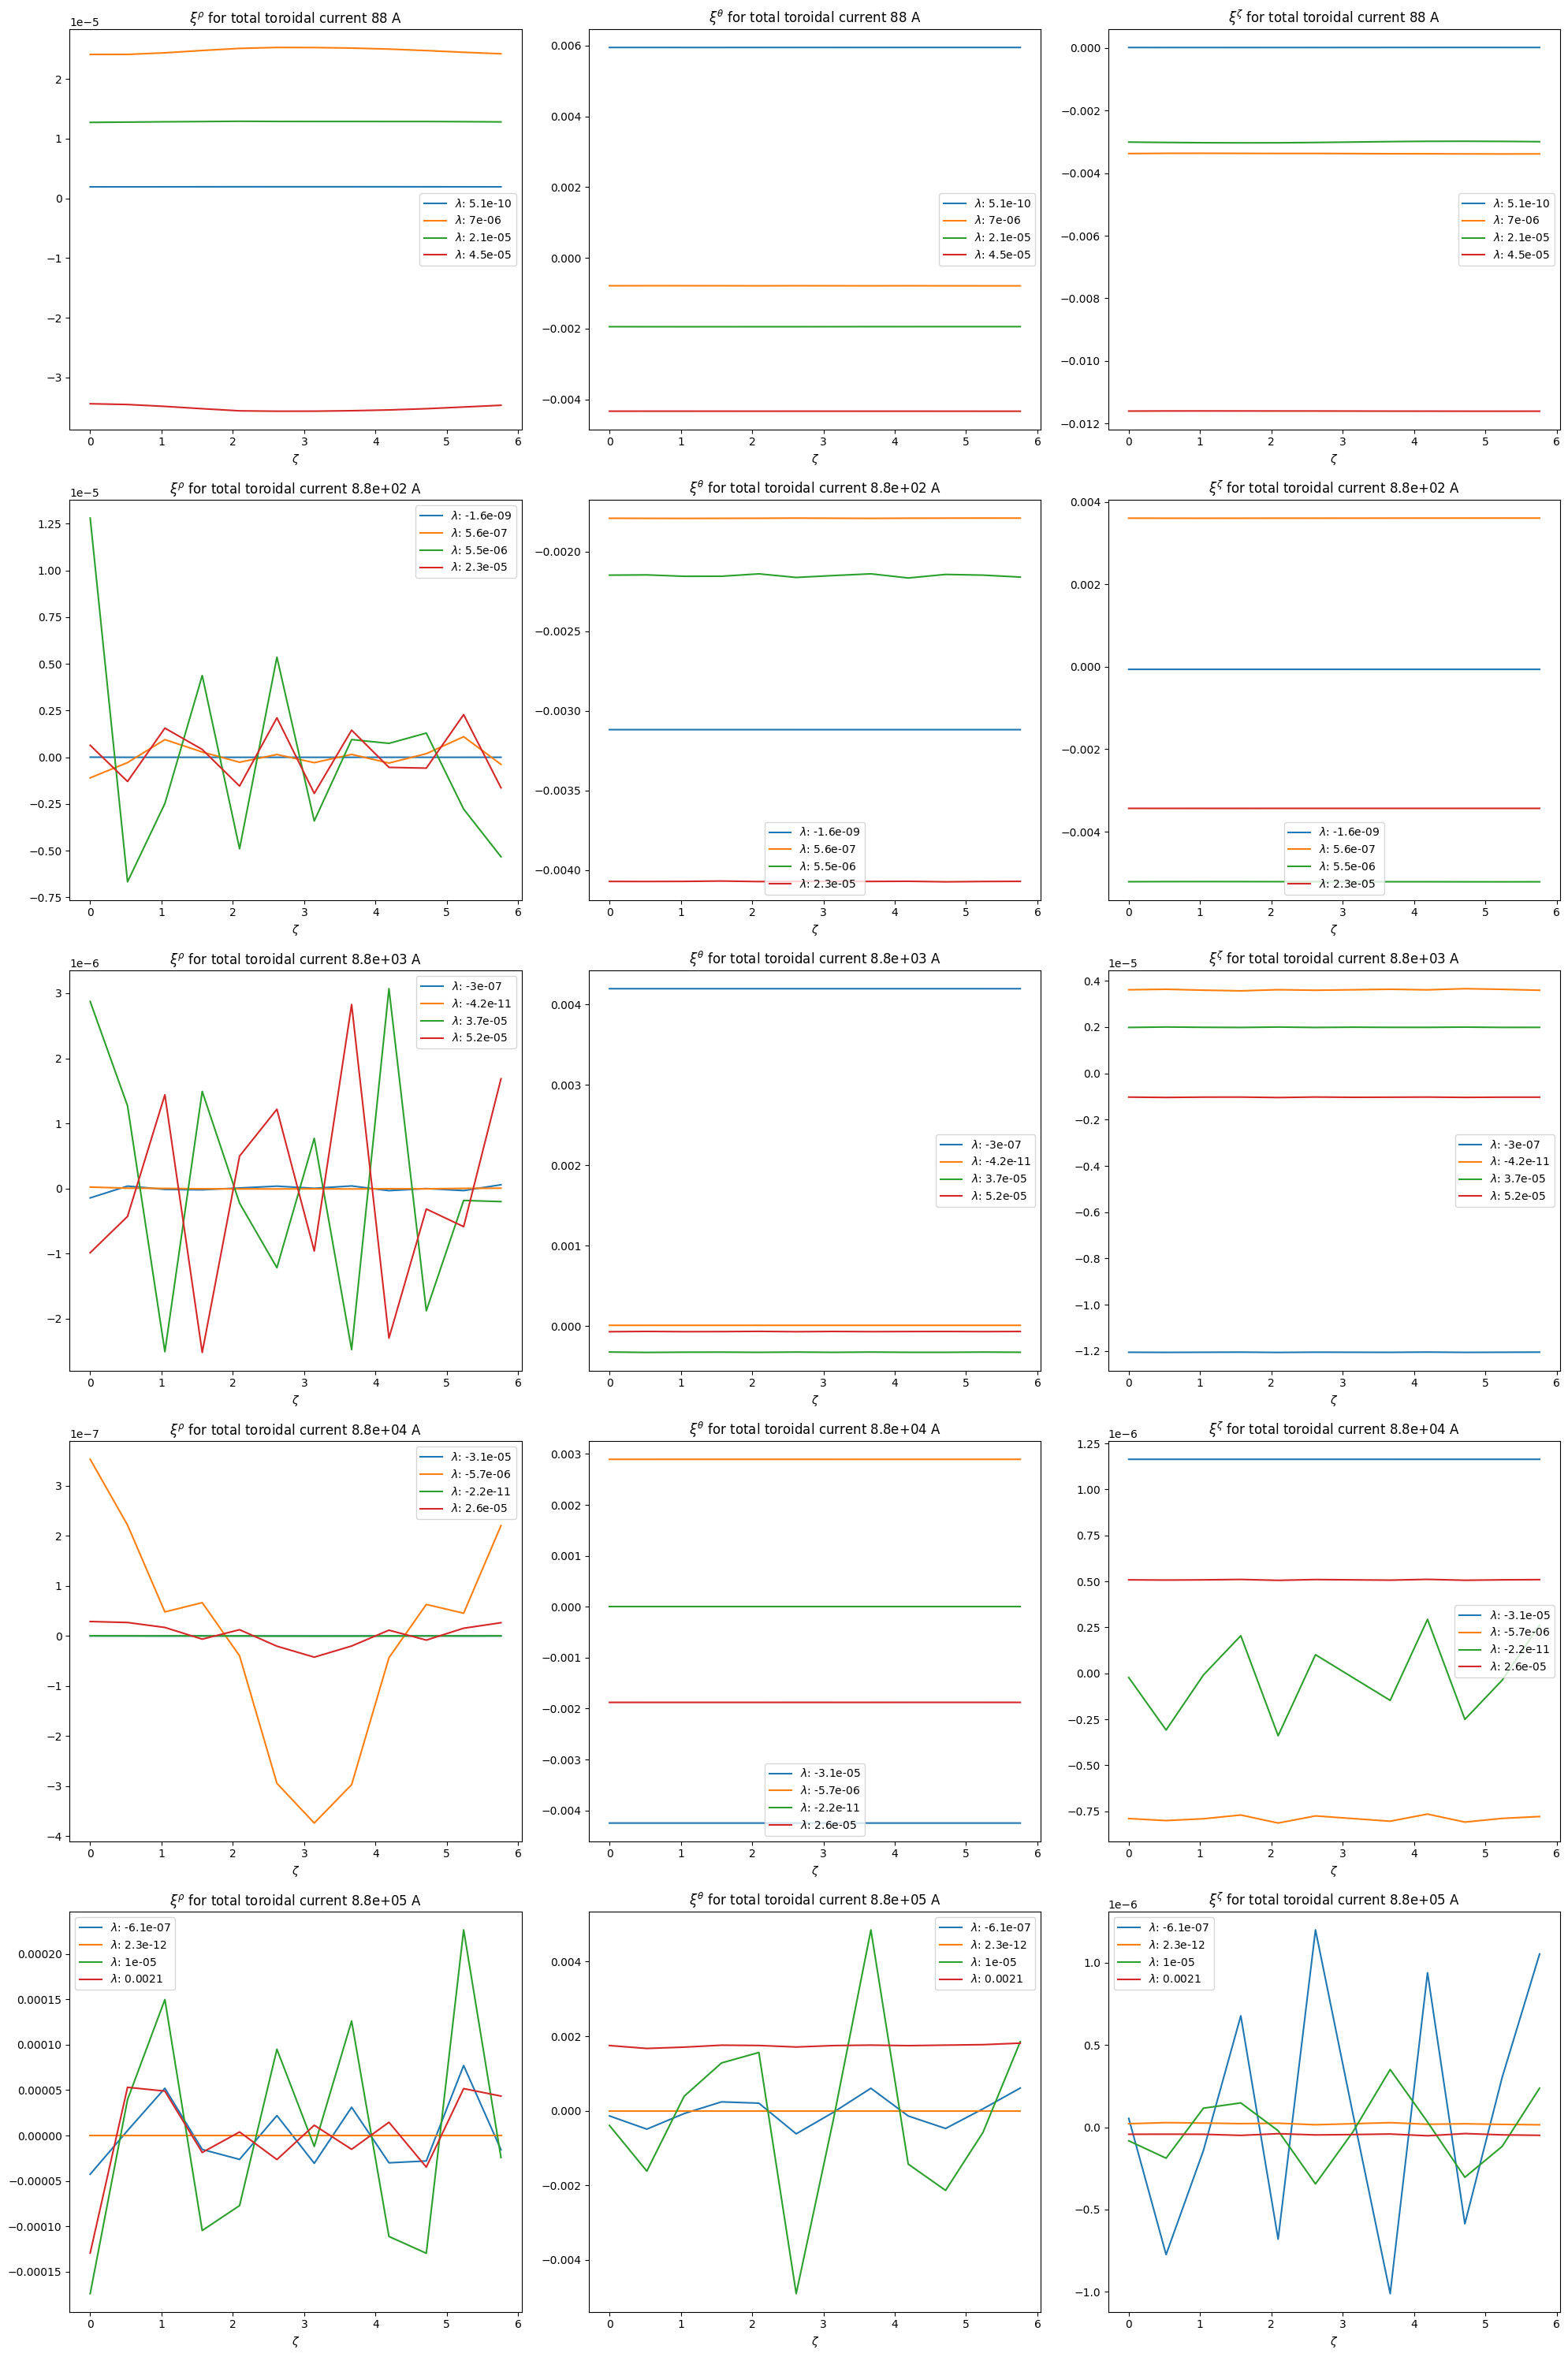

In [139]:
# Plot as a function of zeta
I_multipliers = np.logspace(-2, 2, num=5)
fig, axes = plt.subplots(5,3, figsize=(20, 30))
for I_multiplier, axs in zip(I_multipliers, axes):
    save_tag = get_save_tag(I_coeffs_base, I_multiplier, p_coeffs=p_coeffs, aspect_ratio=200, NFP=1, axisym=False, fixed_iota=False)
    v = np.load(f"{save_dir}eigenfunction_{save_tag}.npy")
    nodes = np.load(f"{save_dir}rtz_nodes_{save_tag}.npy")
    lambdas = np.load(f"{save_dir}lambda_{save_tag}.npy")
    n_rho, n_theta, n_zeta = np.load(f"{save_dir}xi_rho_{save_tag}.npy").shape
    n_total = n_rho * n_theta * n_zeta
    n_lambdas = v.shape[0]
    xi_sup_rho_final = np.reshape(v[:,:n_total], (n_lambdas, n_rho, n_theta, n_zeta))
    xi_sup_theta_final = np.reshape(v[:,n_total:2*n_total], (n_lambdas, n_rho, n_theta, n_zeta))
    xi_sup_zeta_final = np.reshape(v[:,2*n_total:], (n_lambdas, n_rho, n_theta, n_zeta))

    nodes = nodes.reshape((n_rho, n_theta, n_zeta, 3))
    for xi, ax, name in zip([xi_sup_rho_final, xi_sup_theta_final, xi_sup_zeta_final], axs, ["rho", "theta", "zeta"]):
        n_xi = 4
        ax.plot(nodes[n_rho//2,0,:,2],xi[:n_xi,n_rho//2,0,:].T, label = [f"$\\lambda$: {_lambda:.2g}" for _lambda in lambdas[:n_xi]])
        ax.set_title(f"$\\xi^\\{name}$ for total toroidal current {(I_multiplier * integrated_I):.2g} A")
        ax.set_xlabel("$\\zeta$")
        ax.legend()
plt.tight_layout()

# Plotting eigenfunctions

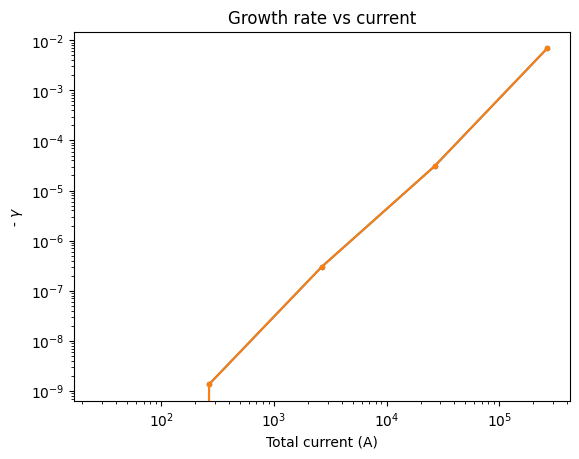

In [5]:
import matplotlib.pyplot as plt

# Input parameters
a = 1  # Minor radius
aspect_ratio = 200  # Aspect ratio of the tokamak
R = aspect_ratio * a  # Major radius
I = 10000  # Plasma current in amps
fig, ax = plt.subplots()
for NFP in [1, 200]:
    NFP = 200  # aspect_ratio  # Number of field periods
    I_multipliers = np.logspace(
        -2, 2, num=5
    )  # Multipliers for the current profile to explore different stability regimes
    # from desc.plotting import plot_1d
    lambdas = []
    axisym = False
    for I_mult in I_multipliers:
        # Input profiles
        fixed_iota = False

        save_name = f"equilibrium_{save_tag}.h5"

        _lambda = np.load(f"{save_dir}lambda_{save_tag}.npy")
        eq = load(f"{save_dir}equilibrium_{save_tag}.h5")
        # plot_1d(eq, "iota")
        lambdas.append(_lambda.min())
    n = 2 * np.arange(len(I_coeffs_base))
    integrated_I = np.sum(I_coeffs_base / (n + 1))
    ax.loglog(integrated_I * I_multipliers, -np.array(lambdas), marker=".")
    ax.set_xlabel("Total current (A)")
    ax.set_ylabel("- $\\gamma$")
    ax.set_title("Growth rate vs current")

In [ ]:
lambdas

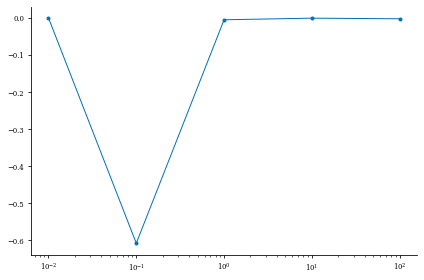

In [5]:
plt.semilogx(I_multipliers, np.array(lambdas), marker=".")

In [31]:
lambdas

[np.float64(7.728903830519953e-07),
 np.float64(-0.6083979572039647),
 np.float64(-0.004981127824734469),
 np.float64(-0.0005950001125584404),
 np.float64(-0.002273794688315304)]

In [23]:
eq.current = eq.get_profile("current", kind="power_series")
eq.current._params

/Users/maya/DESC/desc/utils.py:572: UserWarning: Current on axis is nonzero, got -3.151e-08 Amps
  warnings.warn(msg, err)


array([-3.15111573e-08,  7.16194786e+03,  7.95861633e+02,  7.95781352e+02,
       -1.19289606e-02, -3.19292792e-03, -4.34680863e-03])

In [26]:
PowerSeriesProfile(eq.current._params, sym=True)

array([[ 0,  0,  0],
       [ 2,  0,  0],
       [ 4,  0,  0],
       [ 6,  0,  0],
       [ 8,  0,  0],
       [10,  0,  0],
       [12,  0,  0]])

In [3]:
_lambda = np.load(f"{save_dir}lambda_{save_tag}.npy")
_lambda.min()

np.float64(-0.214177684846096)

rho
[-1] [ 1.06827927e-08 -9.67414830e-08  6.27516138e-08 -1.57419582e-06
 -7.56786729e-08 -1.33635859e-06 -2.48611305e-07 -4.26548491e-08
 -6.05357890e-08  2.34169069e-06  1.43812034e-07 -1.03490841e-06
 -5.79904767e-09  4.93013429e-08  8.69412943e-09 -4.94231704e-08
  8.36592785e-08  1.58732463e-06  2.99255216e-07  4.46513790e-08
  9.37550024e-07  2.36421274e-07  5.12073525e-09 -6.63937990e-06
 -2.53044483e-07  7.24437464e-06  2.74040208e-07  8.79515177e-06
  1.91659335e-07  6.30086004e-07  6.63643258e-06  4.25916515e-03
 -1.10935110e-10 -2.93652819e-08 -8.27224861e-08 -4.95649985e-08
  2.08905577e-08 -6.60610015e-09 -2.25578920e-10 -8.70465707e-10
  5.06674824e-10 -2.93891427e-09  9.67085953e-09 -3.27557184e-09
 -3.75570903e-10  4.77682113e-11  4.86725054e-12  1.64305684e-11
 -4.56558698e-11  6.38228600e-11 -1.04997215e-10  1.28641392e-10
  9.25028267e-11  8.33200622e-11 -1.06789013e-12  1.07030552e-10
  2.09511587e-10  1.79686547e-10 -7.03318604e-11 -5.10749415e-12
  1.60507293e-12

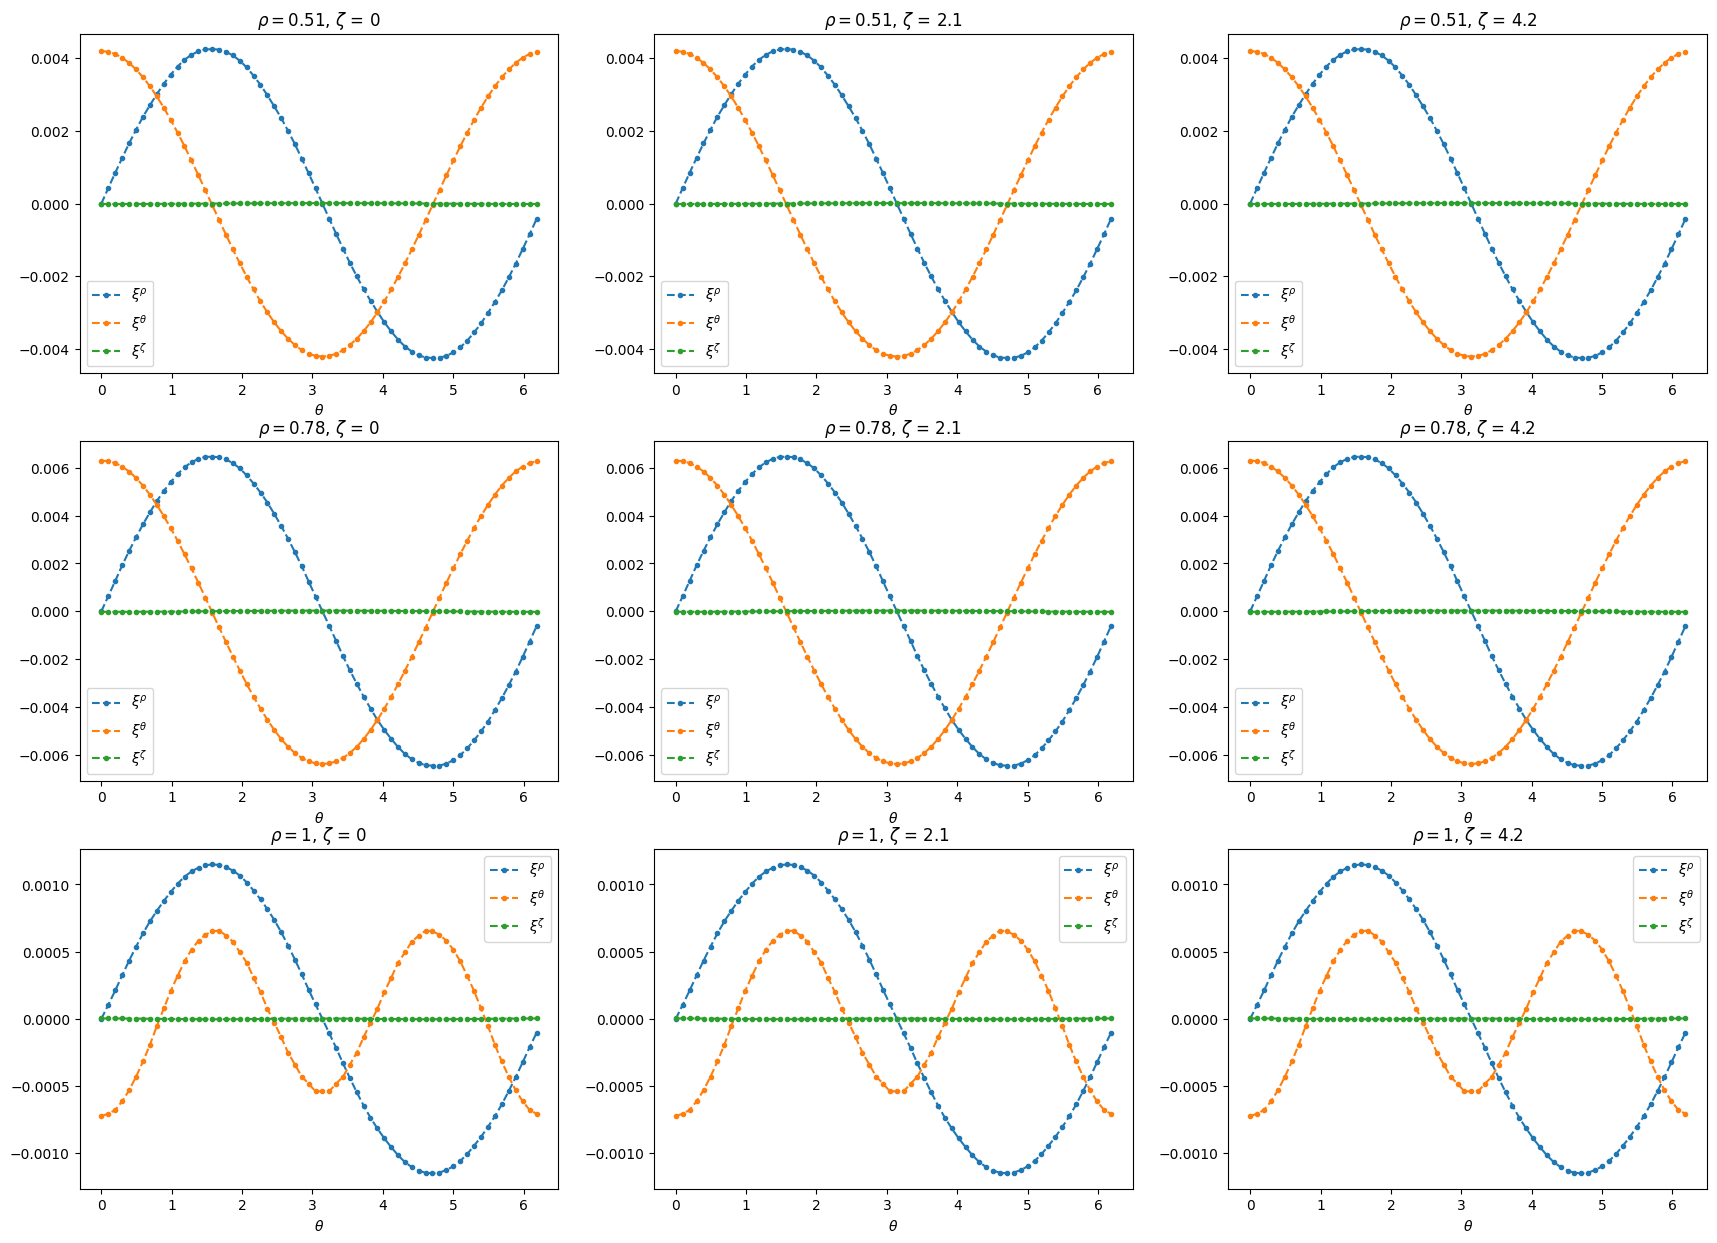

In [93]:
from desc.transform import Transform
from desc.grid import Grid
from desc.basis import ChebyshevDoubleFourierBasis, DoubleFourierSeries
import matplotlib.pyplot as plt
I_coeffs_base = np.array([-3.15111573e-08,  7.16194786e+03,  7.95861633e+02,  7.95781352e+02,
        -1.19289606e-02, -3.19292792e-03, -4.34680863e-03])
I_coeffs = I_coeffs_base * 1
I_profile = PowerSeriesProfile(I_coeffs, sym=True)
iota_coeffs = None
iota_profile = None
p_coeffs = np.array([0.125, 0, 0, 0, -0.125])
p_profile = PowerSeriesProfile(p_coeffs)

NFP = 1
# Save directory and filename
save_path = "./high_aspect_ratio_tokamak/"
profile_tag = f"iota_{"_".join(iota_coeffs.astype(str))}" if fixed_iota else f"I_{"_".join(I_coeffs.astype(str))}"
save_tag = f"axisym_{axisym}_ar_{aspect_ratio}_NFP_{NFP}_p_{"_".join(p_coeffs.astype(str))}_{profile_tag}"
save_name = f"equilibrium_{save_tag}.h5"

rho_inds = [32, 48, -1]
zeta_inds = [0, 4, 8]
fig, axes = plt.subplots(len(zeta_inds), len(rho_inds), figsize=(len(rho_inds)*7,len(zeta_inds)*5))

xi = np.load(f"{save_dir}xi_rho_{save_tag}.npy")
#coeffs = transform.fit(xi.flatten())
#print(np.unique(basis.modes[np.abs(coeffs)>(np.abs(coeffs)*0.01)][:,1]))
n_rho, n_theta, n_zeta = xi.shape
nodes = np.load(f"{save_dir}rtz_nodes_{save_tag}.npy").reshape(n_rho, n_theta, n_zeta, 3)
for name in ["rho", "theta", "zeta"]:
    print(name)
    xi = np.load(f"{save_dir}xi_{name}_{save_tag}.npy")
    #coeffs = transform.fit(xi.flatten())
    #print(np.unique(basis.modes[np.abs(coeffs)>(np.abs(coeffs)*0.01)][:,1]))
    n_rho, n_theta, n_zeta = xi.shape

    for rho_ind, axs in zip(rho_inds, axes):
        for zeta_ind, ax in zip(zeta_inds, axs):
            grid = Grid(nodes=nodes[rho_ind,:,zeta_ind].reshape(-1,3))
            basis = DoubleFourierSeries(M=grid.M, N=0)
            transform = Transform(grid, basis, derivs=0, build=True, build_pinv=True)
            coeffs = transform.fit(xi[rho_ind,:,zeta_ind].flatten())
            mask = np.abs(coeffs) > (np.abs(coeffs).max() * 0.01)
            print(basis.modes[mask][:,1], coeffs)

            rho = nodes[rho_ind,0,zeta_ind,0]
            zeta = nodes[rho_ind,0,zeta_ind,2]
            label = {"$\\xi^{\\"+name+"}$"}
            ax.plot(nodes[rho_ind,:,zeta_ind,1],xi[rho_ind,:,zeta_ind], label=label, linestyle="dashed", marker=".")
            ax.set_xlabel("$\\theta$")
            ax.legend()
            ax.set_title(f"$\\rho={rho:.2g}$, $\\zeta$ = {zeta:.2g}")
    #del(coeffs)
    #del(xi)
plt.legend()

peak to peak: 2e-07
[-5 -4 -3 -2 -1  0  1  3  4  5  6] [ 6.14957196e-23 -1.37445615e-08  8.10578520e-10 -8.06341535e-10
 -5.77276983e-09  3.40023008e-09 -4.58820258e-09 -2.35311242e-08
  3.85672367e-11 -2.11381963e-08 -3.51081387e-08 -2.90788340e-08
 -3.01758446e-08]
Max coefficient with N!=0: 3.51e-08
Dominant mode with N!=0: [0 0 4] with coefficient -3.51e-08
Max coefficient with N=0: 4.59e-09
{'$\\xi^{\\rho}$'}
peak to peak: 4.9e-07
[-5 -2  0  1  2  3  4  5  6] [ 1.69016112e-22  2.62487328e-09  5.18320324e-11  3.45575225e-10
  1.64832582e-09  1.90659749e-10 -3.41473590e-08 -3.27244342e-08
  2.18514935e-08 -6.85741977e-08 -6.93612980e-08 -3.15622251e-08
 -1.32164012e-07]
Max coefficient with N!=0: 1.32e-07
Dominant mode with N!=0: [0 0 6] with coefficient -1.32e-07
Max coefficient with N=0: 3.41e-08
{'$\\xi^{\\rho}$'}
peak to peak: 4.4e-09
[-5 -4 -3 -2 -1  0  1  2  3  4  5  6] [-1.59479932e-24  5.79895448e-10  6.26435646e-11  1.29050460e-10
  1.09743587e-10 -4.44724064e-11  3.6618953

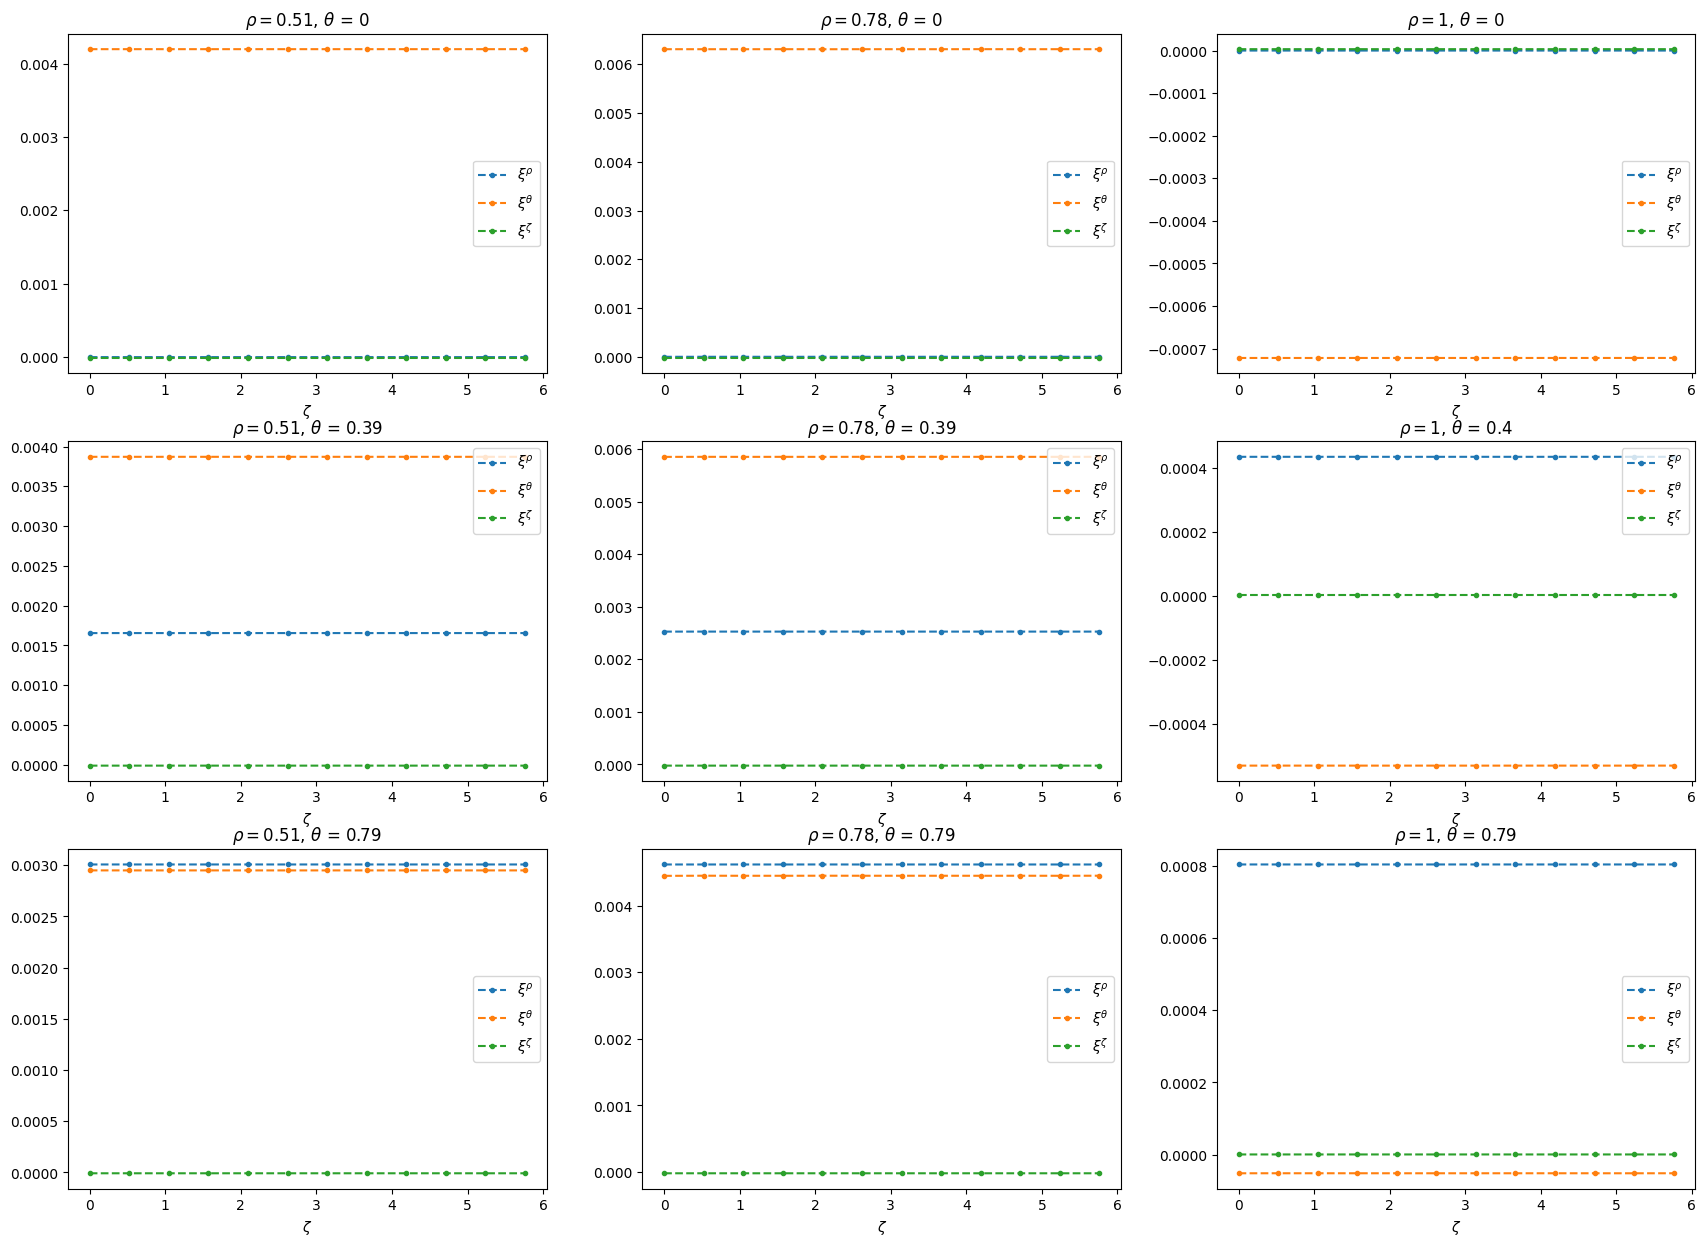

In [105]:
from desc.transform import Transform
from desc.grid import Grid
from desc.basis import ChebyshevDoubleFourierBasis, DoubleFourierSeries
import matplotlib.pyplot as plt
I_coeffs_base = np.array([-3.15111573e-08,  7.16194786e+03,  7.95861633e+02,  7.95781352e+02,
        -1.19289606e-02, -3.19292792e-03, -4.34680863e-03])
I_coeffs = I_coeffs_base * 1
I_profile = PowerSeriesProfile(I_coeffs, sym=True)
iota_coeffs = None
iota_profile = None
p_coeffs = np.array([0.125, 0, 0, 0, -0.125])
p_profile = PowerSeriesProfile(p_coeffs)

# Save directory and filename
save_path = "./high_aspect_ratio_tokamak/"
profile_tag = f"iota_{"_".join(iota_coeffs.astype(str))}" if fixed_iota else f"I_{"_".join(I_coeffs.astype(str))}"
save_tag = f"axisym_{axisym}_ar_{aspect_ratio}_NFP_{NFP}_p_{"_".join(p_coeffs.astype(str))}_{profile_tag}"
save_name = f"equilibrium_{save_tag}.h5"

_lambda = np.load(f"{save_dir}lambda_{save_tag}.npy")
eq = load(f"{save_dir}equilibrium_{save_tag}.h5")
#plot_1d(eq, "iota")
#lambdas.append(_lambda.min())
#grid = Grid(nodes=nodes)
#basis = ChebyshevDoubleFourierBasis(L=64, M=32, N=0)
#transform = Transform(grid, basis, derivs=0, build=True, build_pinv=True)
rho_inds = [32, 48, -1]
theta_inds = [0, 4, 8]
fig, axes = plt.subplots(len(theta_inds), len(rho_inds), figsize=(len(rho_inds)*7,len(theta_inds)*5))
axes = axes.reshape(len(theta_inds), len(rho_inds))

xi = np.load(f"{save_dir}xi_rho_{save_tag}.npy")
#coeffs = transform.fit(xi.flatten())
#print(np.unique(basis.modes[np.abs(coeffs)>(np.abs(coeffs)*0.01)][:,1]))
n_rho, n_theta, n_zeta = xi.shape
nodes = np.load(f"{save_dir}rtz_nodes_{save_tag}.npy").reshape(n_rho, n_theta, n_zeta, 3)

for name in ["rho", "theta", "zeta"]:
    xi = np.load(f"{save_dir}xi_{name}_{save_tag}.npy")
    #coeffs = transform.fit(xi.flatten())
    #print(np.unique(basis.modes[np.abs(coeffs)>(np.abs(coeffs)*0.01)][:,1]))
    n_rho, n_theta, n_zeta = xi.shape

    for theta_ind, axs in zip(theta_inds, axes):
        for rho_ind, ax in zip(rho_inds, axs):
            grid = Grid(nodes=nodes[rho_ind,theta_ind,:].reshape(-1,3))
            basis = DoubleFourierSeries(M=0, N=grid.N)
            transform = Transform(grid, basis, derivs=0, build=True, build_pinv=True)
            coeffs = transform.fit(xi[rho_ind,theta_ind,:].flatten())
            mask = np.abs(coeffs) > (np.abs(coeffs).max() * 0.01)
            print(f"peak to peak: {np.ptp(xi[rho_ind,theta_ind,:]):.2g}")
            print(basis.modes[mask][:,2], coeffs)

            # how closely is it N=0
            mask = (basis.modes[:,2] != 0)
            print(f"Max coefficient with N!=0: {np.abs(coeffs[mask]).max():.2e}")
            print(f"Dominant mode with N!=0: {basis.modes[mask][np.argmax(np.abs(coeffs[mask]))]} with coefficient {coeffs[mask][np.argmax(np.abs(coeffs[mask]))]:.2e}")
            print(f"Max coefficient with N=0: {np.abs(coeffs[~mask]).max():.2e}")

            
            rho = nodes[rho_ind,theta_ind,0,0]
            theta = nodes[rho_ind,theta_ind,0,1]
            label = {"$\\xi^{\\"+name+"}$"}
            print(label)
            ax.plot(nodes[rho_ind,theta_ind,:,2],xi[rho_ind,theta_ind,:], label=label, linestyle="dashed", marker=".")
            ax.set_xlabel("$\\zeta$")
            ax.legend()
            ax.set_title(f"$\\rho={rho:.2g}$, $\\theta$ = {theta:.2g}")
    #del(coeffs)
    #del(xi)
plt.legend()

In [ ]:
147456

Text(0, 0.5, '$\\iota$')

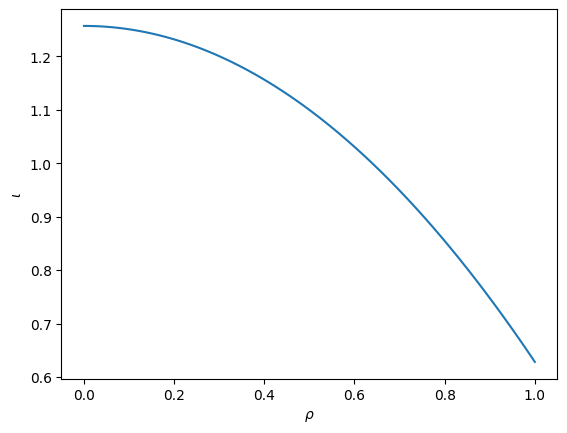

In [10]:
from desc.grid import LinearGrid

plt.plot(
    np.linspace(0, 1, 100), eq.iota.compute(LinearGrid(rho=np.linspace(0, 1, 100)))
)
plt.xlabel("$\\rho$")
plt.ylabel("$\\iota$")

In [8]:
xi_1.shape

(64, 64, 1)

/Users/maya/anaconda3/envs/desc-env/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/maya/anaconda3/envs/desc-env/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Text(0.5, 1.0, '$\\rho=0.51$')

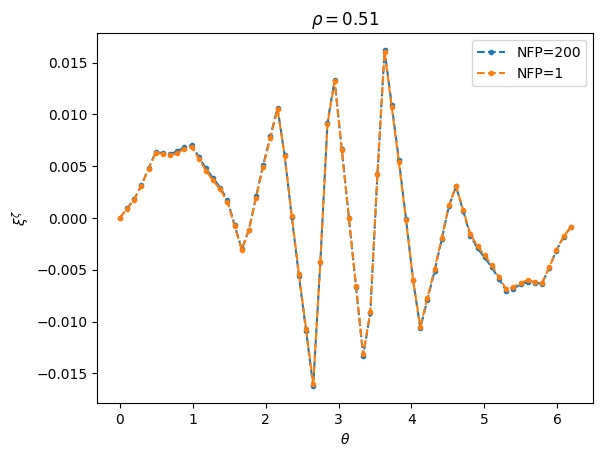

In [14]:
name = "zeta"
ind = 32
save_tag = "axisym_ar_200_NFP_200_p_0.125_0.0_0.0_0.0_-0.125_iota_0.9_0.0_0.1_0.0_0.1"
xi_1 = np.load(f"{save_dir}xi_{name}_{save_tag}.npy")
save_tag = "axisym_ar_200_p_0.125_0.0_0.0_0.0_-0.125_iota_0.9_0.0_0.1_0.0_0.1"
xi_2 = np.load(f"{save_dir}xi_{name}_{save_tag}.npy")
plt.plot(
    nodes.reshape(64, 64, 3)[ind, :, 1],
    xi_1[ind, :],
    label="NFP=200",
    linestyle="dashed",
    marker=".",
)
plt.plot(
    nodes.reshape(64, 64, 3)[ind, :, 1],
    xi_2[ind, :],
    label="NFP=1",
    linestyle="dashed",
    marker=".",
)
plt.xlabel("$\\theta$")
plt.ylabel("$\\xi^{\\" + name + "}$")
plt.legend()
plt.title(f"$\\rho={nodes.reshape(64,64,3)[ind,0,0]:.2f}$")

In [14]:
xi = np.load(f"{save_dir}xi_{name}_{save_tag}.npy")
coeffs = transform.fit(xi.flatten())
print(np.unique(basis.modes[np.abs(coeffs) > (np.abs(coeffs) * 0.01)][:, 1]))
ind = rho_inds[0]
name = "theta"
rho = nodes.reshape(64, 64, 3)[ind, 0, 0]
label = {"$\\xi^{\\" + name + "}$"}
print(label)
ax.plot(nodes.reshape(64, 64, 3)[ind, :, 1], xi[ind, :], label=label)
ax.set_xlabel("$\\theta$")
ax.legend()
ax.set_title(f"$\\rho={rho:.2f}$")

[-32 -31 -30 -29 -28 -27 -26 -25 -24 -23 -22 -21 -20 -19 -18 -17 -16 -15
 -14 -13 -12 -11 -10  -9  -8  -7  -6  -5  -4  -3  -2  -1   0   1   2   3
   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18  19  20  21
  22  23  24  25  26  27  28  29  30  31  32]
{'$\\xi^{\\theta}$'}


/Users/maya/anaconda3/envs/desc-env/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/maya/anaconda3/envs/desc-env/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Text(0.5, 1.0, '$\\rho=0.51$')

: 

(<Figure size 287.717x287.717 with 1 Axes>,
 <Axes: xlabel='$\\rho$', ylabel='$\\langle |\\mathbf{J} \\times \\mathbf{B} - \\nabla p|/\\langle |\\nabla |B|^{2}/(2\\mu_0)| \\rangle_{vol} \\rangle~(~)$'>)

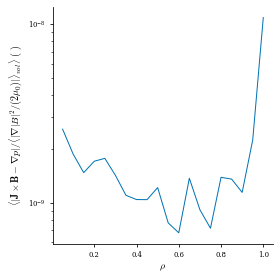

In [ ]:
from desc.plotting import plot_fsa

plot_fsa(eq, "|F|_normalized", log=True)

(<Figure size 287.717x287.717 with 1 Axes>,
 <Axes: xlabel='$\\rho$', ylabel='$ \\iota ~(~)$'>)

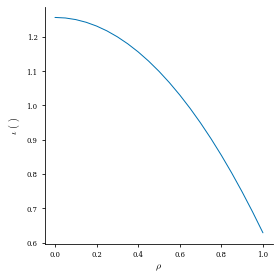

: 

In [5]:
plot_fsa(eq, "iota")

In [96]:
def lobatto(res):
    if res == 0:
        return np.array([1])
    x = (np.cos(np.arange(res, -1, -1) * np.pi / res) + 1) / 2
    x = np.sort(x, axis=None)
    return x


from desc.diffmat_utils import DiffMat, legendre_diffmat, fourier_diffmat
from desc.grid import LinearGrid

rho_nodes = (lobatto(eq.L) + 1e-3) / (
    1 + 2e-3
)  # Slightly inside the boundary to avoid issues
grid = LinearGrid(rho=rho_nodes, M=eq.M, N=eq.N, NFP=eq.NFP)

# grid = ConcentricGrid(L=eq.L, M=eq.M, N=eq.N, node_pattern="cheb1", NFP=eq.NFP)
D_rho, W_rho = legendre_diffmat(grid.num_rho)
D_theta, W_theta = fourier_diffmat(grid.num_theta)
D_zeta, W_zeta = fourier_diffmat(grid.num_zeta)
diffmat = DiffMat(
    D_rho=D_rho,
    D_theta=D_theta,
    D_zeta=D_zeta,
    W_rho=W_rho,
    W_theta=W_theta,
    W_zeta=W_zeta,
)
# Evaluate stability
data = eq.compute("finite-n lambda", diffmat=diffmat, grid=grid)

In [97]:
data["finite-n lambda"].min()

Array(-2.87909975e-08, dtype=float64)

In [88]:
# Step 1 of Newcomb's criterion: Suydam criterion
from scipy.constants import mu_0

data = eq.compute(
    ["iota_r", "iota", "p", "p_r", "B_z", "B_t"], grid=LinearGrid(rho=rho_nodes)
)
r = rho_nodes * a
q = 1 / data["iota"]
q_prime = -1 / data["iota"] ** 2 * data["iota_r"]
p_prime = data["p_r"]
B_z = data["B_z"]
B_theta = data["B_t"]
suydam = r * B_z[:, 0] ** 2 * (q_prime / q) ** 2 + 8 * mu_0 * p_prime
(suydam < 0).any()

Array(True, dtype=bool)

In [91]:
suydam

Array([-0.00072238, -0.06905678, -0.22035936, -0.27080936, -0.11976522,
       -0.00123927], dtype=float64)

In [107]:
# Step 2 of Newcomb's criterion: check for interchanges
k = 1
m = 1
F = k * B_z + m * B_theta

In [15]:
aspect_ratio = 20  # Aspect ratio of the tokamak
a = R / aspect_ratio  # Minor radius

In [29]:
B_z

Array([[-3.18624040e+02,  2.44529570e-18, -2.13726467e-30],
       [-3.17103791e+02,  2.35108880e-16,  1.60391583e-30],
       [-3.13092707e+02,  8.36369256e-16,  3.80178084e-29],
       [-3.08073113e+02,  1.56393653e-15,  1.26742512e-28],
       [-3.03962790e+02,  2.13998209e-15,  3.33638072e-28],
       [-3.02381226e+02,  2.35705706e-15,  4.97134286e-28]],      dtype=float64)

In [106]:
from desc.io import load

eq = load("../desc/examples/HELIOTRON_output.h5")[-1]
rho_nodes = (lobatto(eq.L) + 1e-3) / (1 + 2e-3)
grid = LinearGrid(rho=rho_nodes, M=eq.M, N=eq.N, NFP=eq.NFP)
D_rho, W_rho = legendre_diffmat(grid.num_rho)
D_theta, W_theta = fourier_diffmat(grid.num_theta)
D_zeta, W_zeta = fourier_diffmat(grid.num_zeta)
diffmat = DiffMat(
    D_rho=D_rho,
    D_theta=D_theta,
    D_zeta=D_zeta,
    W_rho=W_rho,
    W_theta=W_theta,
    W_zeta=W_zeta,
)

data = eq.compute("finite-n lambda", diffmat=diffmat, grid=grid)
data["finite-n lambda"].min()

{'A': Array(2.85884931, dtype=float64),
 'iota_num vacuum': Array([-6.35675628e-03, -6.35675628e-03, -6.35675628e-03, ...,
        -8.44724566e+00, -8.44724566e+00, -8.44724566e+00], dtype=float64),
 'iota_den_r': Array([4.9862965 , 4.9862965 , 4.9862965 , ..., 2.21850913, 2.21850913,
        2.21850913], dtype=float64),
 'iota_num_r vacuum': Array([ -6.36943377,  -6.36943377,  -6.36943377, ..., -28.70843486,
        -28.70843486, -28.70843486], dtype=float64),
 'iota_den': Array([0.0049763 , 0.0049763 , 0.0049763 , ..., 4.42373017, 4.42373017,
        4.42373017], dtype=float64),
 'R': Array([10.54618517, 10.54621704, 10.54631068, ...,  9.29667076,
         9.07470906,  8.91085058], dtype=float64),
 'R_r': Array([-1.02147945, -0.98960361, -0.89595549, ..., -1.42872288,
        -1.92984271, -2.27382486], dtype=float64),
 'Z_r': Array([0.        , 0.25074529, 0.48573067, ..., 0.00588339, 0.39658657,
        0.71810467], dtype=float64),
 '0': Array([0., 0., 0., ..., 0., 0., 0.], dtype=fl

# convert to friedberg form

In [1]:
from desc.grid import Grid
from desc.basis import ChebyshevDoubleFourierBasis, DoubleFourierSeries
import matplotlib.pyplot as plt
from desc.profiles import PowerSeriesProfile
from desc.transform import Transform
import numpy as np
I_coeffs_base = np.array([-3.15111573e-08,  7.16194786e+03,  7.95861633e+02,  7.95781352e+02,
        -1.19289606e-02, -3.19292792e-03, -4.34680863e-03])
I_coeffs = I_coeffs_base * 1
I_profile = PowerSeriesProfile(I_coeffs, sym=True)
iota_coeffs = None
iota_profile = None
p_coeffs = np.array([0.125, 0, 0, 0, -0.125])
p_profile = PowerSeriesProfile(p_coeffs)
fixed_iota = False
axisym = False
aspect_ratio = 200
NFP = 1
save_dir = "results/"


# Save directory and filename
save_path = "./high_aspect_ratio_tokamak/"
profile_tag = f"iota_{"_".join(iota_coeffs.astype(str))}" if fixed_iota else f"I_{"_".join(I_coeffs.astype(str))}"
save_tag = f"axisym_{axisym}_ar_{aspect_ratio}_NFP_{NFP}_p_{"_".join(p_coeffs.astype(str))}_{profile_tag}"
save_name = f"equilibrium_{save_tag}.h5"

xi_r = np.load(f"{save_dir}xi_rho_{save_tag}.npy")
n_rho, n_theta, n_zeta = xi.shape


nodes = np.load(f"{save_dir}rtz_nodes_{save_tag}.npy").reshape(n_rho, n_theta, n_zeta, 3)

grid = Grid(nodes=nodes.reshape(-1,3))
basis = ChebyshevDoubleFourierBasis(L=10, M=10, N=3)
transform = Transform(grid, basis, derivs=2, build=True, build_pinv=True)

In [87]:
# Compute m and n

In [35]:
from newcomb import *
from desc.io import load
from desc.utils import safenorm

# Compute xi in Friedberg's notation
eq = load(f"{save_dir}equilibrium_{save_tag}.h5")
grid = Grid(nodes=nodes.reshape(-1, 3))
xi_r_PEST = np.load(f"{save_dir}xi_rho_{save_tag}.npy")  # xi^rho
xi_theta_PEST = np.load(f"{save_dir}xi_theta_{save_tag}.npy")  # xi^theta_PEST
xi_z_PEST = np.load(f"{save_dir}xi_zeta_{save_tag}.npy")  # xi^zeta


data = eq.compute(
    data_keys + ["R0", "a", "e_rho", "e_vartheta", "e_phi", "b", "n_theta", "n_zeta"],
    grid=grid,
)
R0 = data["R0"]
rho = grid.nodes[:, 0]
a = data["a"]
r = grid.nodes[:, 0] * a
B_theta = B_theta_pinch(data, r)
B_z = B_z_pinch(data, R0)

In [51]:
# rahul's stability solver returns the eigenmode in contravariant PEST form
xi_tot = (
    xi_r_PEST.reshape(-1, 1) * data["e_rho"]
    + xi_theta_PEST.reshape(-1, 1) * data["e_vartheta"]
    + xi_z_PEST.reshape(-1, 1) * data["e_phi"]
)
xi_theta = dot(xi_tot, data["e^vartheta"]) * r
xi = (
    xi_r_PEST.flatten()
)  # friedberg's xi is just the radial component of the perturbation
xi_z = dot(xi_tot, data["grad(phi)"]) * R0

# Compute xi in Fourier space to identify dominant mode numbers
xi_r_c = transform.fit(xi.flatten())
xi_theta_c = transform.fit(xi_theta.flatten())
xi_z_c = transform.fit(xi_z.flatten())


mask = np.abs(xi_r_c) > (np.abs(coeffs).max() * 0.01)
m = np.abs(basis.modes[xi_r_c.argmax(), 1])
n = np.abs(basis.modes[xi_r_c.argmax(), 2])

k = -n / R0
# compute eta, xi_parallel
B_mag = safenorm(data["B"], axis=-1)
xi_parallel = (xi_theta * B_theta + xi_z * B_z) / B_mag
eta = (xi_theta * B_z - xi_z * B_theta) / B_mag
b_hat = data["b"]
e_eta = (B_z[:, None] * data["n_theta"] - B_theta[:, None] * data["n_zeta"]) / B_mag[
    :, None
]
Fs, F_daggers = F(grid.nodes[:, 0], data, m, k, a, R0)


# Compute xi in Fourier space
xi_r_c_PEST = transform.fit(xi_r_PEST.flatten())
xi_theta_c_PEST = transform.fit(xi_theta_PEST.flatten())
xi_z_c_PEST = transform.fit(xi_z_PEST.flatten())


# check incompressibility
jac_derivs = eq.compute(
    [
        "sqrt(g)_PEST",
        "(sqrt(g)_PEST_r)|PEST",
        "(sqrt(g)_PEST_v)|PEST",
        "(sqrt(g)_PEST_p)|PEST",
    ],
    grid=grid,
)
J = jac_derivs["sqrt(g)_PEST"]
J_r = jac_derivs["(sqrt(g)_PEST_r)|PEST"]
J_t = jac_derivs["(sqrt(g)_PEST_v)|PEST"]
J_z = jac_derivs["(sqrt(g)_PEST_p)|PEST"]
# div(xi) = 1/sqrt(g) * partial/partial u^i (sqrt(g) xi^i)
div_xi = J_r * xi_r_PEST.flatten() / J + transform.transform(xi_r_c_PEST, dr=1)
div_xi += J_t * xi_theta_PEST.flatten() / J + transform.transform(xi_theta_c_PEST, dt=1)
div_xi += J_z * xi_z_PEST.flatten() / J + transform.transform(xi_z_c_PEST, dz=1)
div_xi

Array([1.69791594e-06, 9.46451462e-07, 3.24761880e-09, ...,
       1.67270474e-02, 1.67266139e-02, 1.67273926e-02], dtype=float64)

In [85]:
# find dominant toroidal mode numbers in xi
mask = np.abs(xi_r_c_PEST) > np.abs(xi_r_c_PEST).max() * 1e-3
mask = mask | (np.abs(xi_theta_c_PEST) > np.abs(xi_theta_c_PEST).max() * 1e-3)
mask = mask | (np.abs(xi_z_c_PEST) > np.abs(xi_z_c_PEST).max() * 1e-3)
np.unique(basis.modes[mask, 2])

array([0])

In [78]:
basis.modes[np.abs(xi_theta_c_PEST) > 1e-5]

array([[ 0,  0,  0],
       [ 0,  1,  0],
       [ 0,  2,  0],
       [ 1,  0,  0],
       [ 1,  1,  0],
       [ 1,  2,  0],
       [ 2,  1,  0],
       [ 2,  2,  0],
       [ 3,  1,  0],
       [ 3,  2,  0],
       [ 4,  1,  0],
       [ 4,  2,  0],
       [ 5,  1,  0],
       [ 5,  2,  0],
       [ 6,  1,  0],
       [ 6,  2,  0],
       [ 7,  1,  0],
       [ 7,  2,  0],
       [ 8,  1,  0],
       [ 8,  2,  0],
       [ 9,  1,  0],
       [10,  1,  0],
       [10,  2,  0]])

In [80]:
basis.modes[np.abs(xi_z_c_PEST) > 1e-5]

array([[0, 1, 0],
       [1, 1, 0]])

In [68]:
Fs, F_daggers = F(rho, data, m, k, a, R0)
k0_sq = k**2 + (m / r) ** 2
rho

Array([0.01, 0.01, 0.01, ..., 1.  , 1.  , 1.  ], dtype=float64)

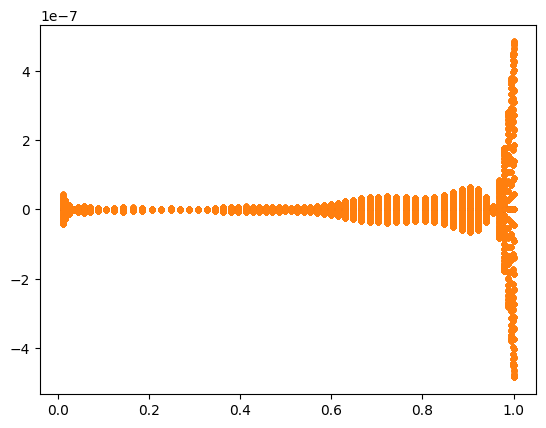

In [56]:
f, g = fg(rho, data, m, k, a, R0)

u_coeffs = transform.fit(f * xi)
dudr = transform.transform(u_coeffs, dr=1)
plt.plot(grid.nodes[:, 0], g * xi, linestyle="none", marker=".", label="g*xi")
plt.plot(grid.nodes[:, 0], dudr, linestyle="none", marker=".", label="du/dr")

In [72]:
p_prime = data["p_r"] / a  # dp/dr
term1 = 2 * mu_0 * (k**2 / k0_sq) * p_prime
term2 = ((k0_sq * r**2 - 1) / (k0_sq * r**2)) * r * (Fs**2)
term3 = (2 * k**2 / (r * k0_sq**2)) * Fs * F_daggers
g = term1 + term2 + term3
term2

Array([4.55497916e-24, 4.55497916e-24, 4.55497916e-24, ...,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00], dtype=float64)